In [ ]:
# import numpy as np
# import scienceplots
# import matplotlib.pyplot as plt
# plt.style.use('science')

# def plot_phanet_output_schematic():
#     np.random.seed(42)
    
#     # 时间轴 (Time steps)
#     cycles = np.linspace(0, 100, 300)
    
#     # A. 预测均值 (Predicted Mean, \bar{\mu}_t)
#     # 模拟平滑单调的退化趋势 (Smooth, Monotonic)
#     # 使用指数衰减模拟电池老化
#     mu_pred = 1.0 - 0.004 * cycles - 0.00001 * cycles**2
    
#     # B. 真实值 (Ground Truth, y_true)
#     # 在平滑趋势上叠加：
#     # 1. 随机噪声 (Aleatoric noise)
#     # 2. 局部容量再生/非单调波动 (Non-monotonic regeneration, sin wave)
#     regeneration_effect = 0.015 * np.sin(cycles * 0.15) * np.exp(-cycles * 0.01)
#     noise = np.random.normal(0, 0.003, len(cycles))
    
#     y_true = mu_pred + regeneration_effect + noise
    
#     # C. 不确定性/置信区间 (Confidence Interval Bounds)
#     # 区间宽度 = 基础宽度 + 对波动的自适应 (模拟模型对非单调区域的不确定性感知)
#     # 当波动大时，sigma 变大
#     sigma_base = 0.01
#     sigma_adaptive = 0.01 * np.abs(np.sin(cycles * 0.15)) # 模拟认知不确定性
#     sigma_tot = sigma_base + sigma_adaptive
    
#     # 校准系数 lambda (假设 lambda_cp = 1.96 for 95% coverage)
#     lambda_cp = 1.96
    
#     upper_bound = mu_pred + lambda_cp * sigma_tot
#     lower_bound = mu_pred - lambda_cp * sigma_tot

#     fig, ax = plt.subplots()
    
#     # 去除顶部和右侧边框
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
    
#     # 1. 绘制置信区间 (阴影区域)
#     # 使用浅蓝色，半透明，代表 Safety Interval
#     ax.fill_between(cycles, lower_bound, upper_bound, 
#                     color='#E1F5FE', alpha=0.8, 
#                     label='Safety Interval (Coverage)')
    
#     # 绘制区间边界线 (可选，增加轮廓感)
#     ax.plot(cycles, upper_bound, color='#039BE5', linewidth=0.5, alpha=0.3)
#     ax.plot(cycles, lower_bound, color='#039BE5', linewidth=0.5, alpha=0.3)

#     # 2. 绘制预测均值 (平滑单调线)
#     # 蓝色虚线或实线，代表先验趋势
#     ax.plot(cycles, mu_pred, color='#0277BD', linewidth=2.5, linestyle='--', 
#             label=r'Prediction $\bar{\mu}_t$ (Smooth/Monotonic)')
    
#     # 3. 绘制真实值 (波动非单调线)
#     # 黑色或深灰色实线，代表真实工况
#     ax.plot(cycles, y_true, color='#424242', linewidth=1.5, alpha=0.9)

#     ax.set_xticks([])
#     ax.set_yticks([])
    


#     plt.tight_layout()
#     plt.show()

# plot_phanet_output_schematic()

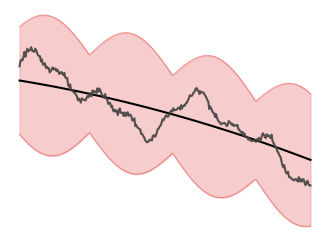

In [19]:
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

# 尝试使用 science 风格
try:
    plt.style.use(['science', 'no-latex'])
except:
    plt.style.use('default')

def plot_phanet_output_schematic():
    np.random.seed(123) 
    
    # 时间轴
    cycles = np.linspace(0, 100, 300)
    
    # ==========================================
    # 1. 预测均值 (平缓单调)
    # ==========================================
    mu_pred = 0.92 - 0.0012 * cycles - 0.000008 * cycles**2
    
    # ==========================================
    # 2. 真实值 (无规律波动)
    # ==========================================
    wave_low = 0.05 * np.sin(cycles * 0.11 + 0.5)
    wave_mid = 0.03 * np.cos(cycles * 0.23 - 1.0)
    wave_high = 0.015 * np.sin(cycles * 0.53)
    noise = np.random.normal(0, 0.004, len(cycles))
    
    fluctuation = wave_low + wave_mid + wave_high
    y_true = mu_pred + fluctuation + noise + 0.03
    
    # ==========================================
    # 3. 不确定性区间
    # ==========================================
    sigma_base = 0.03
    sigma_adaptive = 0.04 * np.abs(np.sin(cycles * 0.11 + 0.5)) + 0.02
    sigma_tot = sigma_base + sigma_adaptive
    lambda_cp = 1.96
    
    upper_bound = mu_pred + lambda_cp * sigma_tot + 0.03
    lower_bound = mu_pred - lambda_cp * sigma_tot + 0.03

    # ==========================================
    # 绘图配置
    # ==========================================
    fig, ax = plt.subplots()
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # A. 绘制置信区间 (低饱和度红色系)
    # 使用 muted red / dusty red 颜色
    # 填充色使用低透明度，边界线稍微深一点
    fill_color = '#EF9A9A'  # 浅红/低饱和红 (Material Red 200)
    edge_color = '#E53935'  # 稍微深一点的红 (Material Red 600)
    
    ax.fill_between(cycles, lower_bound, upper_bound, 
                    color=fill_color, alpha=0.5, # alpha 调低让红色不刺眼
                    label='Safety Interval')
    
    # 区间边界线 (细线，勾勒轮廓)
    ax.plot(cycles, upper_bound, color=edge_color, linewidth=0.8, alpha=0.4)
    ax.plot(cycles, lower_bound, color=edge_color, linewidth=0.8, alpha=0.4)

    # B. 绘制预测均值 (黑色虚线)
    # 黑色，粗虚线，代表单调的基准
    ax.plot(cycles, mu_pred + 0.03, color='black', linewidth=1.5, linestyle='-', 
            label=r'Prediction $\bar{\mu}_t$')
    
    # C. 绘制真实值 (深灰色实线)
    # 使用深灰色而不是纯黑，以免和预测线混在一起，保留层次感
    ax.plot(cycles, y_true, color='#424242', linewidth=1.5, alpha=0.9, 
            label='Ground Truth')

    # 去除刻度
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()
    # plt.show()
    plt.savefig('phanet_output.png', dpi=600, bbox_inches='tight', pad_inches=0.1, transparent=True)

if __name__ == "__main__":
    plot_phanet_output_schematic()